In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\Collage\self\New folder\Project\CSV_file\pipeline_sensor_data_1M.csv")

print(df.shape)
df.head()

(187624, 50)


,timestamp,flow,pressure,acoustic,anomaly,hour,day,month,zone_Aleem Nagar,zone_Almas Nagar,...,zone_Sharda Nagar,zone_Shegaon,zone_Shyam Nagar,zone_Somwar Bazar,zone_Sutgirni,zone_Tapovan,zone_VMV Area,zone_Wadarpura,zone_Walgaon Road,zone_Ziri
0,2026-03-05 21:49:17.995908,101.220417,55.040061,24.205546,0,21,5,3,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2026-03-05 21:49:18.995908,92.791317,48.743370,23.355619,0,21,5,3,True,False,...,False,False,False,False,False,False,False,False,False,False
2,2026-03-05 21:49:20.995908,104.652380,59.225662,29.012009,0,21,5,3,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2026-03-05 21:49:22.995908,96.689024,54.845878,25.628342,0,21,5,3,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2026-03-05 21:49:23.995908,95.464410,55.359204,23.750985,0,21,5,3,False,False,...,False,False,False,False,False,False,False,False,False,False


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187624 entries, 0 to 187623
Data columns (total 50 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   timestamp                   187624 non-null  object 
 1   flow                        187624 non-null  float64
 2   pressure                    187624 non-null  float64
 3   acoustic                    187624 non-null  float64
 4   anomaly                     187624 non-null  int64  
 5   hour                        187624 non-null  int64  
 6   day                         187624 non-null  int64  
 7   month                       187624 non-null  int64  
 8   zone_Aleem Nagar            187624 non-null  bool   
 9   zone_Almas Nagar            187624 non-null  bool   
 10  zone_Ambika Nagar           187624 non-null  bool   
 11  zone_Badnera                187624 non-null  bool   
 12  zone_Baripura               187624 non-null  bool   
 13  zone_Benoda Bh

,flow,pressure,acoustic,anomaly,hour,day,month
count,187624.000000,187624.000000,187624.000000,187624.0,187624.000000,187624.000000,187624.0
mean,100.021274,54.989419,25.013545,0.0,11.033695,6.586748,3.0
std,4.892842,2.948520,1.962376,0.0,7.379665,0.717473,0.0
min,86.091048,46.106400,19.430591,0.0,0.000000,5.000000,3.0
25%,96.666499,52.971892,23.667948,0.0,4.000000,6.000000,3.0
50%,100.012720,55.000951,25.008156,0.0,11.000000,7.000000,3.0
75%,103.359648,57.006055,26.349952,0.0,18.000000,7.000000,3.0
max,114.747165,63.376019,30.915476,0.0,23.000000,8.000000,3.0


In [4]:
df.isnull().sum()


timestamp                     0
flow                          0
pressure                      0
acoustic                      0
anomaly                       0
hour                          0
day                           0
month                         0
zone_Aleem Nagar              0
zone_Almas Nagar              0
zone_Ambika Nagar             0
zone_Badnera                  0
zone_Baripura                 0
zone_Benoda Bhimtekdi         0
zone_Bhaji Bazar              0
zone_Budhwara                 0
zone_Camp Area                0
zone_Daryapur Gate            0
zone_Dastur Nagar             0
zone_Gadge Nagar              0
zone_Gadgeshwar               0
zone_Gandhi Chowk             0
zone_Gaurakshan               0
zone_Gawalipura               0
zone_Jalaram Nagar            0
zone_Jawahar Gate             0
zone_Jevad Nagar              0
zone_Kiran Nagar              0
zone_Maltekdi                 0
zone_Mehadiya Colony          0
zone_Nawathe Plot             0
zone_Nem

In [5]:
df = df.drop_duplicates()

In [6]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [7]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [9]:
df = df[df["flow"] > 0]
df = df[df["pressure"] > 0]
df = df[df["acoustic"] > 0]

In [10]:
Q1 = df[["flow","pressure","acoustic"]].quantile(0.25)
Q3 = df[["flow","pressure","acoustic"]].quantile(0.75)

IQR = Q3 - Q1

df = df[~((df[["flow","pressure","acoustic"]] < (Q1 - 1.5 * IQR)) |
          (df[["flow","pressure","acoustic"]] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [12]:
print(df["anomaly"].value_counts())

anomaly
0    185880
Name: count, dtype: int64


In [13]:
df.reset_index(drop=True, inplace=True)

In [14]:
df.to_csv(r"D:\Collage\self\New folder\Project\CSV_file\pipeline_sensor_data_1M.csv", index=False)

In [15]:
#Exploratory Data Analysis


In [16]:
# Check anomaly distribution
df["anomaly"].value_counts()


anomaly
0    185880
Name: count, dtype: int64

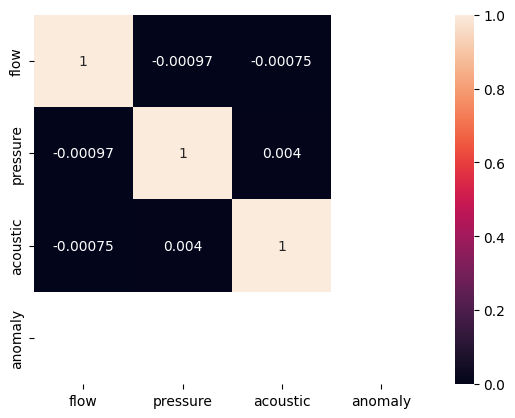

In [17]:
# Check correlation
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df[["flow","pressure","acoustic","anomaly"]].corr(), annot=True)
plt.show()

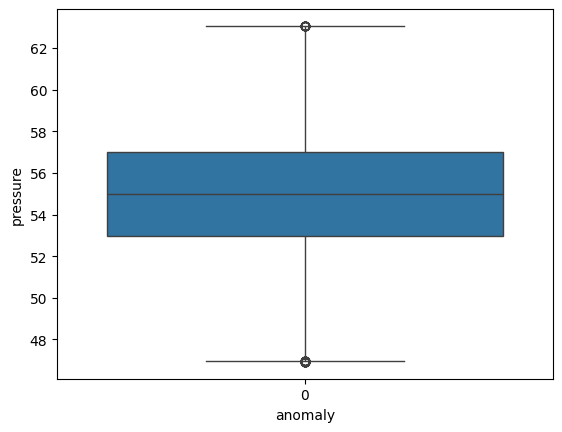

In [18]:
# Visualize leak vs normal
sns.boxplot(x="anomaly", y="pressure", data=df)
plt.show()

In [19]:
X = df.drop(["timestamp","anomaly"], axis=1)
y = df["anomaly"]

In [20]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,        # more trees → better detection
    contamination=0.05,      # expected % of anomalies
    max_samples="auto",
    random_state=42,
    n_jobs=-1                # use full CPU
)

iso_model.fit(X_scaled)

,n_estimators,200
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [37]:
iso_pred = iso_model.predict(X_scaled)

In [38]:
df["iso_anomaly"] = iso_pred
df["iso_anomaly"] = df["iso_anomaly"].map({1:0, -1:1})

In [41]:
from sklearn.metrics import classification_report
print(classification_report(df["anomaly"], df["iso_anomaly"]))

C:\Users\bodhe\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bodhe\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       1.00      0.95      0.97    185880
           1       0.00      0.00      0.00         0

    accuracy                           0.95    185880
   macro avg       0.50      0.47      0.49    185880
weighted avg       1.00      0.95      0.97    185880



C:\Users\bodhe\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop(["timestamp","anomaly","iso_anomaly"], axis=1, errors="ignore")
y = df["anomaly"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37176

    accuracy                           1.00     37176
   macro avg       1.00      1.00      1.00     37176
weighted avg       1.00      1.00      1.00     37176



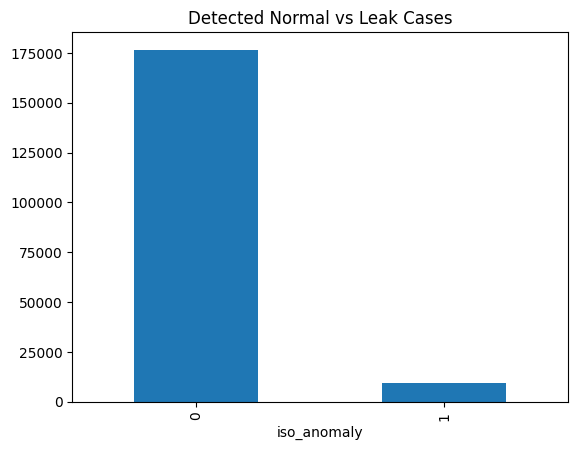

In [43]:
import matplotlib.pyplot as plt

df["iso_anomaly"].value_counts().plot(kind="bar")
plt.title("Detected Normal vs Leak Cases")
plt.show()

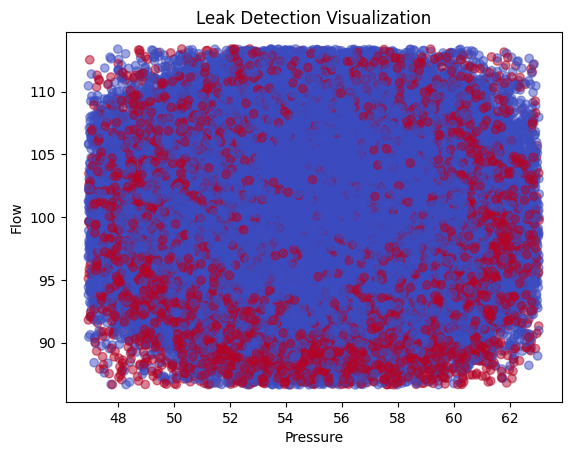

In [44]:
plt.scatter(df["pressure"], df["flow"],
            c=df["iso_anomaly"], cmap="coolwarm", alpha=0.5)

plt.xlabel("Pressure")
plt.ylabel("Flow")
plt.title("Leak Detection Visualization")
plt.show()

In [46]:
import joblib

joblib.dump(rf_model, "leak_detection_rf_model.pkl")
joblib.dump(iso_model, "leak_detection_iso_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [47]:
model = joblib.load("leak_detection_rf_model.pkl")